In [2]:
%pip install pandas sqlalchemy pymysql cryptography

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import sqlalchemy
import pymysql
print("pandas", pd.__version__)
print("sqlalchemy", sqlalchemy.__version__)
print("pymysql", pymysql.__version__)

pandas 2.3.3
sqlalchemy 2.0.43
pymysql 2.2.8


In [4]:
import pandas as pd
from getpass import getpass
from urllib.parse import quote_plus
from sqlalchemy import create_engine

user = "root"          # change this if your MySQL user is different
host = "localhost"
port = 3306
database = "nyc_airbnb"

password = getpass("root: ")   # a box appears; type your real password and press Enter

engine = create_engine(
    f"mysql+pymysql://{user}:{quote_plus(password)}@{host}:{port}/{database}"
)

df = pd.read_sql("SELECT * FROM listings_clean", engine)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print(list(df.columns))

root:  ········


Rows: 48819
Columns: 18
['row_id', 'id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'price_valid']


In [5]:
# --- fix column types ---
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")
df["reviews_per_month"] = pd.to_numeric(df["reviews_per_month"], errors="coerce")

# --- data check ---
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Nulls per column:")
print(df.isna().sum())
print()
print("Duplicate ids:", df["id"].duplicated().sum())
print("price_valid counts:", df["price_valid"].value_counts().to_dict())
print("Price range (price_valid = 1):", df.loc[df.price_valid == 1, "price"].min(), "to", df.loc[df.price_valid == 1, "price"].max())
print("Max minimum_nights:", df["minimum_nights"].max())
print("Review dates:", df["last_review"].min(), "to", df["last_review"].max())
print()
print(df["neighbourhood_group"].value_counts())
print(df["room_type"].value_counts())

Shape: (48819, 18)

row_id                                     int64
id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
price_valid                                int64
dtype: object

Nulls per column:
row_id                                0
id                       

In [6]:
print("Nulls:", df.isna().sum()[df.isna().sum() > 0].to_dict())
print("Duplicate ids:", df["id"].duplicated().sum())
print("price_valid:", df["price_valid"].value_counts().to_dict())
print("Price (valid):", df.loc[df.price_valid == 1, "price"].min(), "to", df.loc[df.price_valid == 1, "price"].max())
print("Max minimum_nights:", df["minimum_nights"].max())
print("Review dates:", df["last_review"].min(), "to", df["last_review"].max())
print(df["neighbourhood_group"].value_counts().to_dict())
print(df["room_type"].value_counts().to_dict())

Nulls: {'last_review': 10018, 'reviews_per_month': 10018}
Duplicate ids: 0
price_valid: {1: 48808, 0: 11}
Price (valid): 10 to 4500
Max minimum_nights: 365
Review dates: 2011-03-28 00:00:00 to 2019-07-08 00:00:00
{'Manhattan': 21621, 'Brooklyn': 20076, 'Queens': 5661, 'Bronx': 1089, 'Staten Island': 372}
{'Entire home/apt': 25364, 'Private room': 22297, 'Shared room': 1158}


In [7]:
import os
os.makedirs("charts", exist_ok=True)

df.to_csv("nyc_airbnb_clean.csv", index=False)
print("Saved to:", os.path.abspath("nyc_airbnb_clean.csv"))

check = pd.read_csv("nyc_airbnb_clean.csv")
print("Re-read shape:", check.shape)

Saved to: C:\Users\hp\nyc_airbnb_clean.csv
Re-read shape: (48819, 18)


Listings: 48819 | valid-price listings: 48808
Median price: $106 | Mean price: $149.1
Share priced above $500: 2.1%
                     listings  median_price  share_%
neighbourhood_group                                 
Manhattan               21621         150.0     44.3
Brooklyn                20076          90.0     41.1
Queens                   5661          75.0     11.6
Bronx                    1089          65.0      2.2
Staten Island             372          75.0      0.8
                 listings  median_price  share_%
room_type                                       
Entire home/apt     25364         160.0     52.0
Private room        22297          70.0     45.7
Shared room          1158          45.0      2.4
neighbourhood
Williamsburg          3915
Bedford-Stuyvesant    3710
Harlem                2652
Bushwick              2461
Upper West Side       1966
Hell's Kitchen        1954
East Village          1852
Upper East Side       1795
Crown Heights         1562
Midtown    

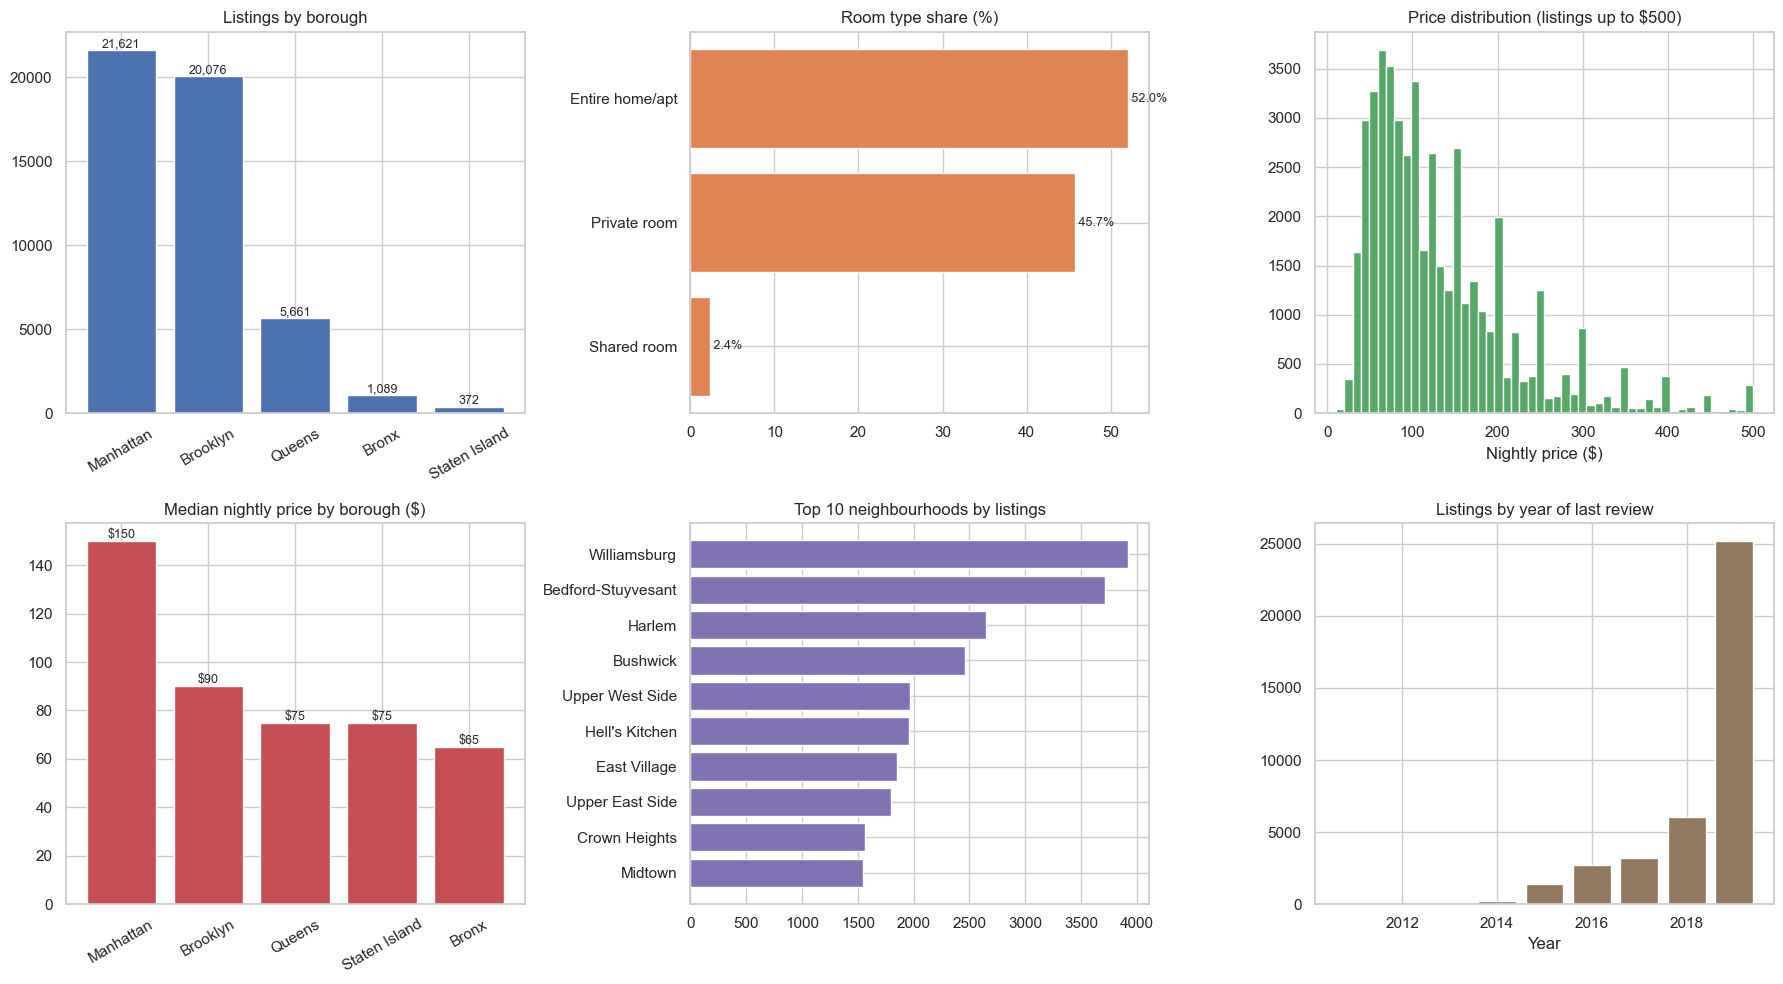

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

valid = df[df.price_valid == 1]   # price analysis uses valid prices only

print("Listings:", len(df), "| valid-price listings:", len(valid))
print("Median price: $%.0f | Mean price: $%.1f" % (valid.price.median(), valid.price.mean()))
print("Share priced above $500: %.1f%%" % ((valid.price > 500).mean() * 100))

borough = (df.groupby("neighbourhood_group").agg(listings=("id", "count"))
             .join(valid.groupby("neighbourhood_group").price.median().rename("median_price"))
             .sort_values("listings", ascending=False))
borough["share_%"] = (borough.listings / borough.listings.sum() * 100).round(1)
print(borough)

room = (df.groupby("room_type").agg(listings=("id", "count"))
          .join(valid.groupby("room_type").price.median().rename("median_price"))
          .sort_values("listings", ascending=False))
room["share_%"] = (room.listings / room.listings.sum() * 100).round(1)
print(room)

top_n = df["neighbourhood"].value_counts().head(10)
print(top_n)

by_year = df["last_review"].dt.year.value_counts().sort_index()
print(by_year)

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

b = borough.listings
ax[0,0].bar(b.index, b.values, color=sns.color_palette("deep")[0])
ax[0,0].set_title("Listings by borough"); ax[0,0].tick_params(axis="x", rotation=30)
for i, v in enumerate(b.values): ax[0,0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

r = room["share_%"]
ax[0,1].barh(r.index[::-1], r.values[::-1], color=sns.color_palette("deep")[1])
ax[0,1].set_title("Room type share (%)")
for i, v in enumerate(r.values[::-1]): ax[0,1].text(v, i, f" {v}%", va="center", fontsize=9)

ax[0,2].hist(valid.loc[valid.price <= 500, "price"], bins=50, color=sns.color_palette("deep")[2])
ax[0,2].set_title("Price distribution (listings up to $500)"); ax[0,2].set_xlabel("Nightly price ($)")

m = borough.median_price.sort_values(ascending=False)
ax[1,0].bar(m.index, m.values, color=sns.color_palette("deep")[3])
ax[1,0].set_title("Median nightly price by borough ($)"); ax[1,0].tick_params(axis="x", rotation=30)
for i, v in enumerate(m.values): ax[1,0].text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=9)

ax[1,1].barh(top_n.index[::-1], top_n.values[::-1], color=sns.color_palette("deep")[4])
ax[1,1].set_title("Top 10 neighbourhoods by listings")

ax[1,2].bar(by_year.index.astype(int), by_year.values, color=sns.color_palette("deep")[5])
ax[1,2].set_title("Listings by year of last review"); ax[1,2].set_xlabel("Year")

plt.tight_layout()
plt.savefig("charts/01_overview.png", dpi=150, bbox_inches="tight")
plt.show()

Median price: borough x room type
 room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          100.0          54.0         40.0
Brooklyn                       145.0          65.0         36.0
Manhattan                      190.0          90.0         69.0
Queens                         120.0          60.0         37.0
Staten Island                  100.0          50.0         30.0 

Listings: borough x room type
 room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                            378           652           59
Brooklyn                        9546         10117          413
Manhattan                      13171          7971          479
Queens                          2094          3369          198
Staten Island                    175           188            9 

Median reviews/month (reviewed lis

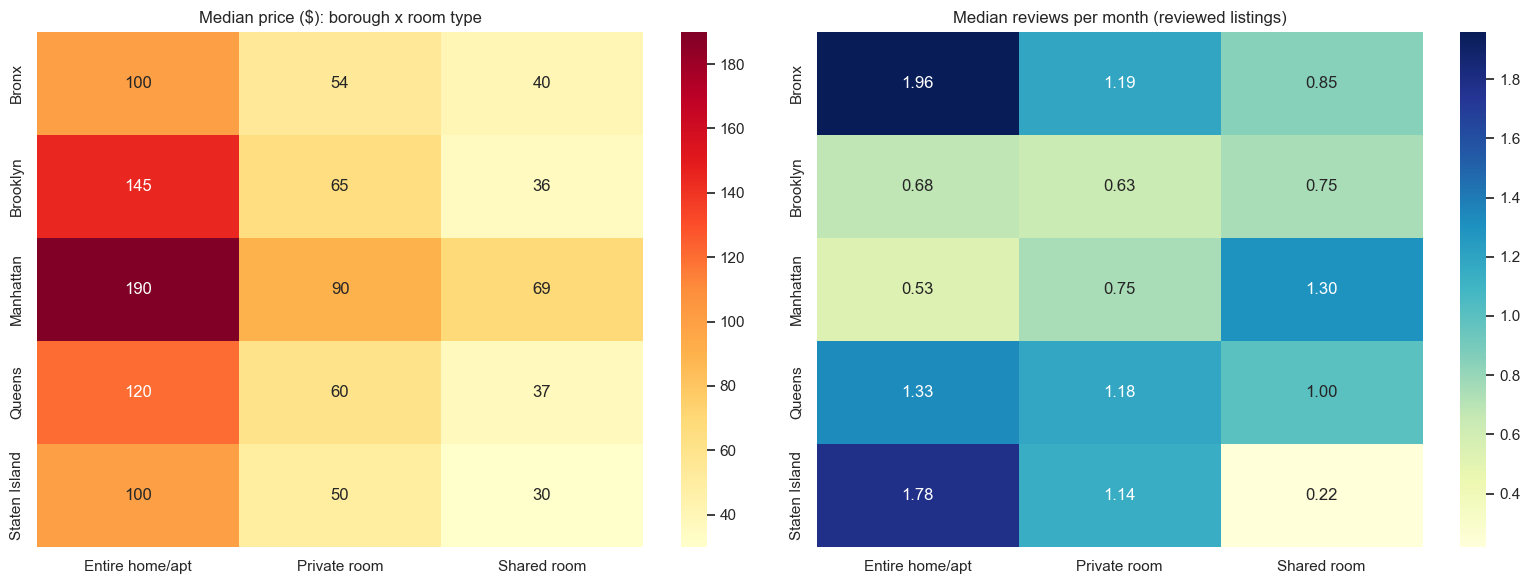

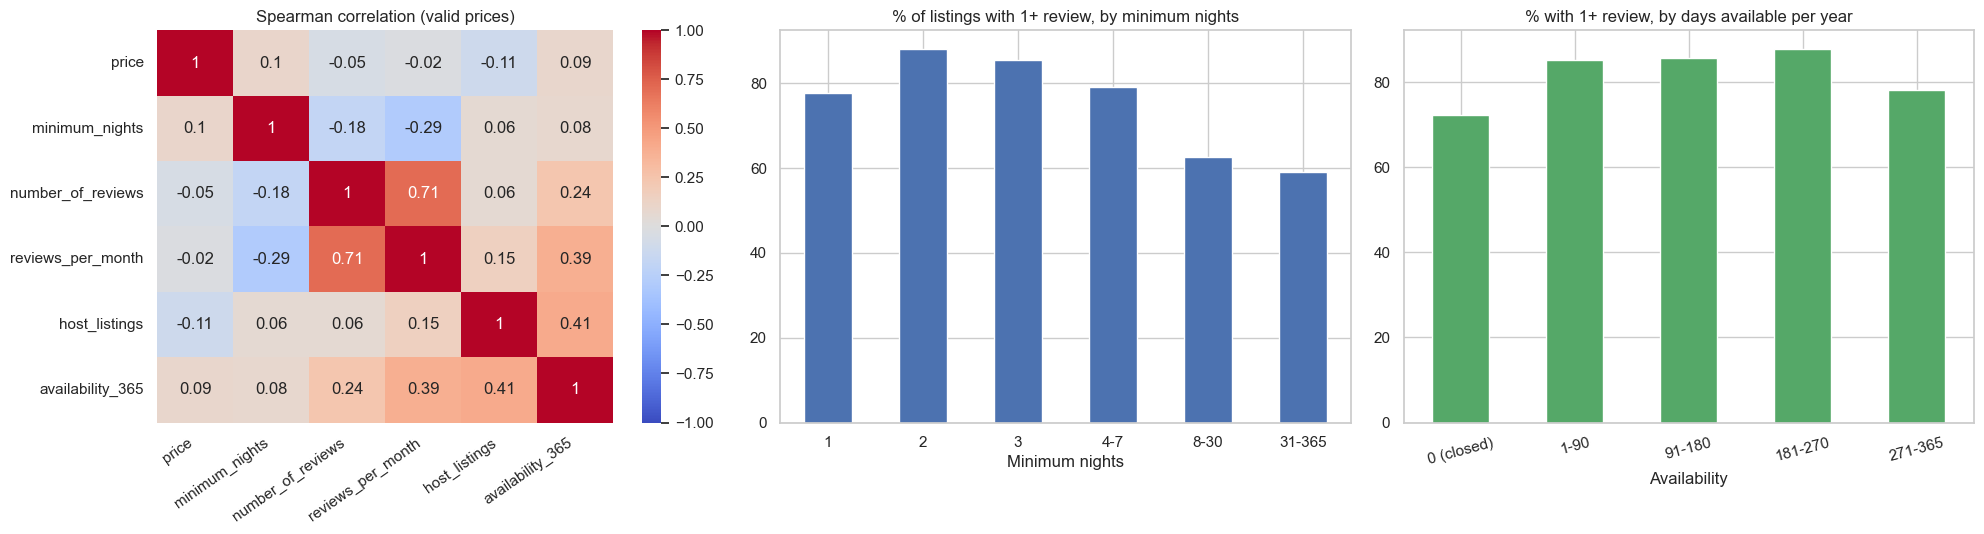

In [9]:
# --- helper columns ---
df["has_review"] = (df.number_of_reviews > 0).astype(int)
df["min_nights_band"] = pd.cut(df.minimum_nights, [0,1,2,3,7,30,365],
                               labels=["1","2","3","4-7","8-30","31-365"])
df["avail_band"] = pd.cut(df.availability_365, [-1,0,90,180,270,365],
                          labels=["0 (closed)","1-90","91-180","181-270","271-365"])

valid = df[df.price_valid == 1]      # price analysis: valid prices only
reviewed = df[df.has_review == 1]    # reviews_per_month exists only for reviewed listings

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

# --- cross-tabs: borough x room type ---
pt_price = valid.pivot_table(index="neighbourhood_group", columns="room_type", values="price", aggfunc="median")
pt_count = df.pivot_table(index="neighbourhood_group", columns="room_type", values="id", aggfunc="count")
pt_rpm = reviewed.pivot_table(index="neighbourhood_group", columns="room_type",
                              values="reviews_per_month", aggfunc="median").round(2)
print("Median price: borough x room type\n", pt_price, "\n")
print("Listings: borough x room type\n", pt_count, "\n")
print("Median reviews/month (reviewed listings)\n", pt_rpm, "\n")

# --- % never reviewed ---
print("% never reviewed by room type:",
      (1 - df.groupby("room_type").has_review.mean()).mul(100).round(1).to_dict())
print("% never reviewed by borough:",
      (1 - df.groupby("neighbourhood_group").has_review.mean()).mul(100).round(1).to_dict(), "\n")

# --- bands ---
mn = df.groupby("min_nights_band", observed=True).agg(
    listings=("id","count"),
    pct_reviewed=("has_review", lambda s: round(s.mean()*100, 1)),
    median_reviews=("number_of_reviews","median"))
av = df.groupby("avail_band", observed=True).agg(
    listings=("id","count"),
    pct_reviewed=("has_review", lambda s: round(s.mean()*100, 1)),
    median_reviews=("number_of_reviews","median"))
print(mn, "\n"); print(av, "\n")

# --- correlation (Spearman, because price and reviews are heavily skewed) ---
num_cols = ["price","minimum_nights","number_of_reviews","reviews_per_month",
            "calculated_host_listings_count","availability_365"]
corr = valid[num_cols].corr(method="spearman").round(2)
print(corr)

# --- figure 1: cross-tab heatmaps ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pt_price, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax[0])
ax[0].set_title("Median price ($): borough x room type"); ax[0].set_xlabel(""); ax[0].set_ylabel("")
sns.heatmap(pt_rpm, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax[1])
ax[1].set_title("Median reviews per month (reviewed listings)"); ax[1].set_xlabel(""); ax[1].set_ylabel("")
plt.tight_layout(); plt.savefig("charts/02_drivers_crosstabs.png", dpi=150, bbox_inches="tight"); plt.show()

# --- figure 2: correlation + bands ---
short = lambda cols: [c.replace("calculated_host_listings_count","host_listings") for c in cols]
fig, ax = plt.subplots(1, 3, figsize=(20, 5.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title("Spearman correlation (valid prices)")
ax[0].set_xticklabels(short(corr.columns), rotation=35, ha="right")
ax[0].set_yticklabels(short(corr.index), rotation=0)
mn.pct_reviewed.plot(kind="bar", ax=ax[1], color=sns.color_palette("deep")[0])
ax[1].set_title("% of listings with 1+ review, by minimum nights"); ax[1].set_xlabel("Minimum nights"); ax[1].tick_params(axis="x", rotation=0)
av.pct_reviewed.plot(kind="bar", ax=ax[2], color=sns.color_palette("deep")[2])
ax[2].set_title("% with 1+ review, by days available per year"); ax[2].set_xlabel("Availability"); ax[2].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.savefig("charts/03_drivers_corr_bands.png", dpi=150, bbox_inches="tight"); plt.show()

1) Sample size and spread (entire homes with reviews)
                        n   q25  median   q75
neighbourhood_group                          
Bronx                 308  0.68    1.96  3.25
Brooklyn             8154  0.19    0.68  2.06
Manhattan            9954  0.16    0.53  1.63
Queens               1741  0.34    1.33  3.00
Staten Island         150  0.82    1.78  2.88 

2) Listing mix: % of entire homes with minimum nights 8+, and % closed (0 days available)
                     pct_min_nights_8plus  pct_closed_0_days
neighbourhood_group                                         
Bronx                                 7.7               16.1
Brooklyn                             12.4               36.5
Manhattan                            24.7               36.1
Queens                                9.1               26.1
Staten Island                         7.4               13.7 

3) Median reviews/month within the same minimum-nights band
mn_band               1-2   3-7  8-30  31-3

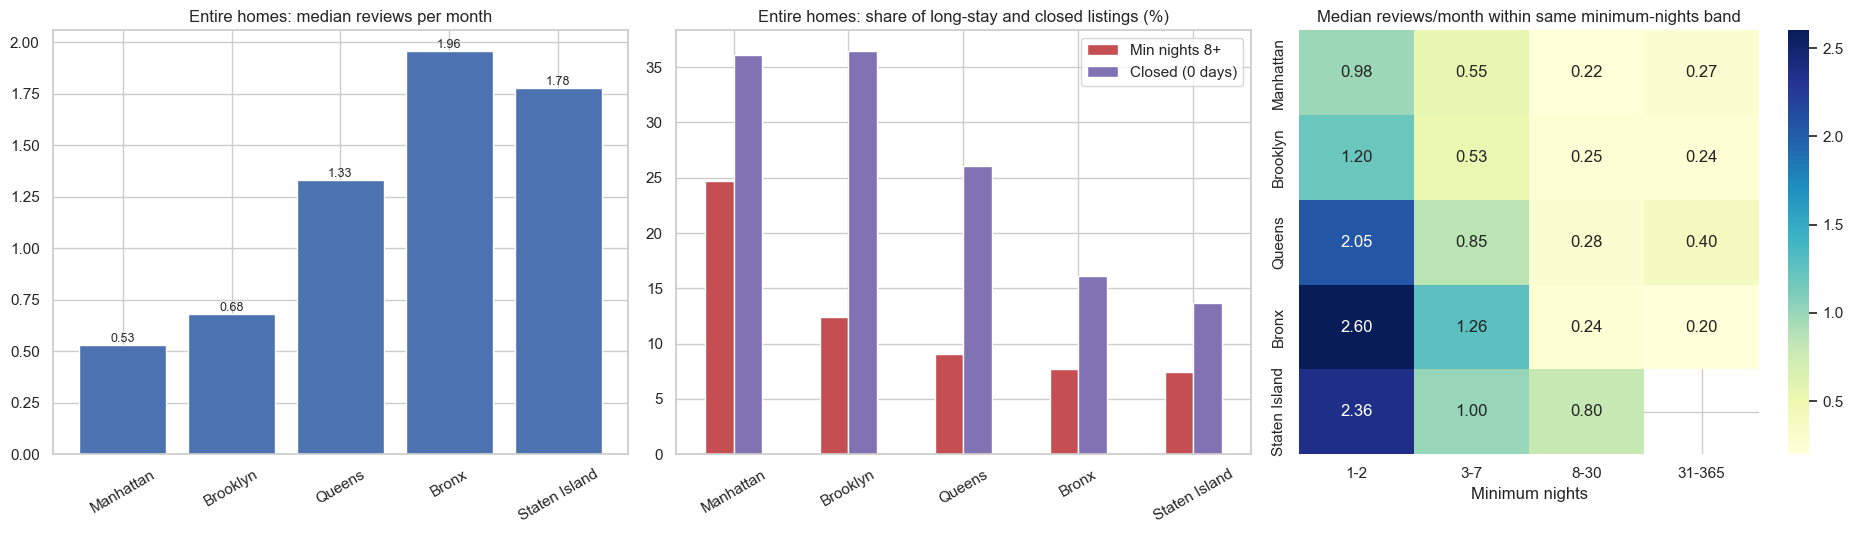

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
os.makedirs("charts", exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

# --- helper columns ---
df["has_review"] = (df.number_of_reviews > 0).astype(int)

entire = df[df.room_type == "Entire home/apt"].copy()
entire["mn_band"] = pd.cut(entire.minimum_nights, [0,2,7,30,365], labels=["1-2","3-7","8-30","31-365"])
entire["host_type"] = np.where(entire.calculated_host_listings_count == 1, "single-listing host", "multi-listing host")
ent_rev = entire[entire.has_review == 1]      # reviews_per_month exists only for reviewed listings

print("1) Sample size and spread (entire homes with reviews)")
g = ent_rev.groupby("neighbourhood_group").reviews_per_month
spread = pd.DataFrame({"n": g.size(), "q25": g.quantile(.25).round(2),
                       "median": g.median().round(2), "q75": g.quantile(.75).round(2)})
print(spread, "\n")

print("2) Listing mix: % of entire homes with minimum nights 8+, and % closed (0 days available)")
mix = pd.DataFrame({
    "pct_min_nights_8plus": entire.groupby("neighbourhood_group").minimum_nights.apply(lambda s: round((s >= 8).mean()*100, 1)),
    "pct_closed_0_days":    entire.groupby("neighbourhood_group").availability_365.apply(lambda s: round((s == 0).mean()*100, 1)),
})
print(mix, "\n")

print("3) Median reviews/month within the same minimum-nights band")
by_mn = ent_rev.pivot_table(index="neighbourhood_group", columns="mn_band",
                            values="reviews_per_month", aggfunc="median", observed=True).round(2)
print(by_mn, "\n")

print("4) Median reviews/month by host type")
by_host = ent_rev.pivot_table(index="neighbourhood_group", columns="host_type",
                              values="reviews_per_month", aggfunc="median").round(2)
print(by_host, "\n")

print("5) Only listings reviewed in 2019 (recently active)")
rec = (ent_rev[ent_rev.last_review >= "2019-01-01"]
       .groupby("neighbourhood_group").reviews_per_month.agg(n="count", median="median").round(2))
print(rec)

# --- chart ---
order = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))

overall = spread["median"].reindex(order)
ax[0].bar(order, overall.values, color=sns.color_palette("deep")[0])
ax[0].set_title("Entire homes: median reviews per month"); ax[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(overall.values):
    ax[0].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

mix.reindex(order).plot(kind="bar", ax=ax[1], color=[sns.color_palette("deep")[3], sns.color_palette("deep")[4]])
ax[1].set_title("Entire homes: share of long-stay and closed listings (%)")
ax[1].tick_params(axis="x", rotation=30); ax[1].set_xlabel("")
ax[1].legend(["Min nights 8+", "Closed (0 days)"])

sns.heatmap(by_mn.reindex(order), annot=True, fmt=".2f", cmap="YlGnBu", ax=ax[2])
ax[2].set_title("Median reviews/month within same minimum-nights band")
ax[2].set_xlabel("Minimum nights"); ax[2].set_ylabel("")

plt.tight_layout()
plt.savefig("charts/04_drilldown_manhattan.png", dpi=150, bbox_inches="tight")
plt.show()

1) Price band vs review activity
            listings  pct_reviewed  median_reviews  median_reviews_per_month
price_band                                                                  
<$50            5010          79.4             4.0                      0.70
$50-99         16834          82.5             6.0                      0.80
$100-149       10019          82.2             6.0                      0.66
$150-199        7194          80.6             6.0                      0.63
$200-299        5862          74.2             4.0                      0.68
$300-499        2680          68.2             3.0                      0.83
$500+           1209          59.7             1.0                      0.61 

2) Median reviews/month: room type x price band
 price_band       <$50  $50-99  $100-149  $150-199  $200-299  $300-499  $500+
room_type                                                                   
Entire home/apt  1.33    0.67      0.58      0.63      0.69      0.86

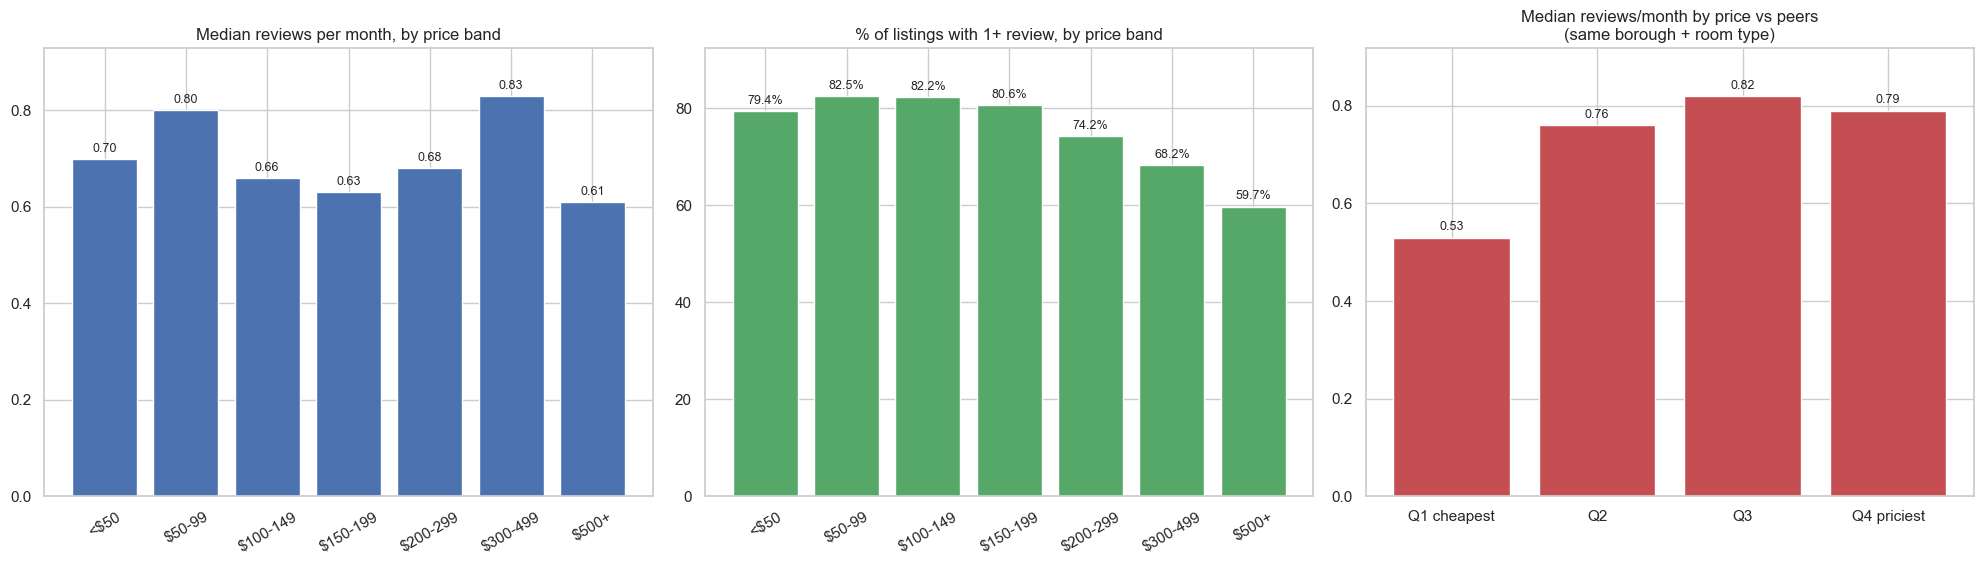

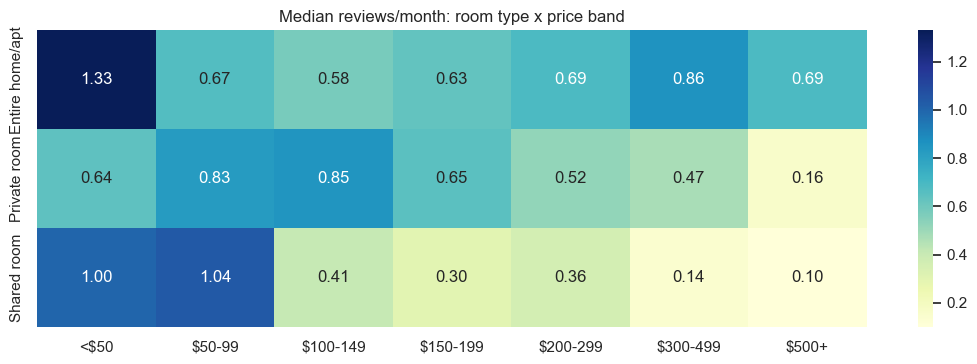

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
os.makedirs("charts", exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def label_bars(ax, fmt="{:,.0f}", suffix="", pad=3):
    """Write the value on top of every bar."""
    for c in ax.containers:
        ax.bar_label(c, labels=[(fmt.format(v) + suffix) if np.isfinite(v) else "" for v in c.datavalues],
                     padding=pad, fontsize=9)
    ax.margins(y=0.12)

df["has_review"] = (df.number_of_reviews > 0).astype(int)
valid = df[df.price_valid == 1].copy()

# --- price bands ---
bins = [0, 49, 99, 149, 199, 299, 499, 5000]
labels = ["<$50", "$50-99", "$100-149", "$150-199", "$200-299", "$300-499", "$500+"]
valid["price_band"] = pd.cut(valid.price, bins, labels=labels)

pb = valid.groupby("price_band", observed=True).agg(
    listings=("id", "count"),
    pct_reviewed=("has_review", lambda s: round(s.mean()*100, 1)),
    median_reviews=("number_of_reviews", "median"),
)
pb["median_reviews_per_month"] = (valid[valid.has_review == 1]
        .groupby("price_band", observed=True).reviews_per_month.median().round(2))
print("1) Price band vs review activity"); print(pb, "\n")

# --- room type x price band ---
rt = valid[valid.has_review == 1].pivot_table(index="room_type", columns="price_band",
        values="reviews_per_month", aggfunc="median", observed=True).round(2)
rt_n = valid[valid.has_review == 1].pivot_table(index="room_type", columns="price_band",
        values="reviews_per_month", aggfunc="count", observed=True)
print("2) Median reviews/month: room type x price band\n", rt, "\n")
print("Number of listings behind each cell\n", rt_n, "\n")

# --- price relative to peers (same borough + room type) ---
valid["peer_quartile"] = valid.groupby(["neighbourhood_group", "room_type"]).price.transform(
    lambda s: pd.qcut(s.rank(method="first"), 4, labels=["Q1 cheapest", "Q2", "Q3", "Q4 priciest"]))
qrt = (valid[valid.has_review == 1].groupby("peer_quartile", observed=True)
       .agg(listings=("id", "count"), median_reviews_per_month=("reviews_per_month", "median"),
            median_reviews=("number_of_reviews", "median")).round(2))
print("3) Price relative to peers (same borough + room type)\n", qrt, "\n")

qb = valid[valid.has_review == 1].pivot_table(index="neighbourhood_group", columns="peer_quartile",
        values="reviews_per_month", aggfunc="median", observed=True).round(2)
print("By borough\n", qb)

# --- figure 1: labelled bars ---
fig, ax = plt.subplots(1, 3, figsize=(20, 5.8))

ax[0].bar(pb.index.astype(str), pb.median_reviews_per_month.values, color=sns.color_palette("deep")[0])
ax[0].set_title("Median reviews per month, by price band"); ax[0].tick_params(axis="x", rotation=30)
label_bars(ax[0], "{:.2f}")

ax[1].bar(pb.index.astype(str), pb.pct_reviewed.values, color=sns.color_palette("deep")[2])
ax[1].set_title("% of listings with 1+ review, by price band"); ax[1].tick_params(axis="x", rotation=30)
label_bars(ax[1], "{:.1f}", "%")

ax[2].bar(qrt.index.astype(str), qrt.median_reviews_per_month.values, color=sns.color_palette("deep")[3])
ax[2].set_title("Median reviews/month by price vs peers\n(same borough + room type)")
label_bars(ax[2], "{:.2f}")

plt.tight_layout()
plt.savefig("charts/05_value_price_vs_reviews.png", dpi=150, bbox_inches="tight")
plt.show()

# --- figure 2: room type x price band heatmap ---
fig, ax = plt.subplots(figsize=(11, 3.8))
sns.heatmap(rt, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Median reviews/month: room type x price band"); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.savefig("charts/06_value_roomtype_priceband.png", dpi=150, bbox_inches="tight")
plt.show()

Hosts: 37394 | listings: 48819 | avg listings per host: 1.31
Hosts with 1 listing: 32246 (86.2%)
Hosts with 2+ listings: 5148 (13.8%), owning 33.9% of listings
Top 10 hosts own 2.6% of listings | top 1% of hosts own 10.1%

1) Host size bands (listings per host)
            hosts  listings  pct_entire_home  pct_closed  pct_reviewed  share_of_listings_%  median_price  median_reviews_per_month
host_band                                                                                                                         
1          32242     32242             58.8        46.2          78.5                 66.0         119.0                      0.56
2           3328      6652             38.0        26.1          86.5                 13.6          90.0                      1.00
3-5         1479      5134             27.1        13.4          87.9                 10.5          79.0                      1.36
6-20         307      2586             29.7         5.7          77.9             

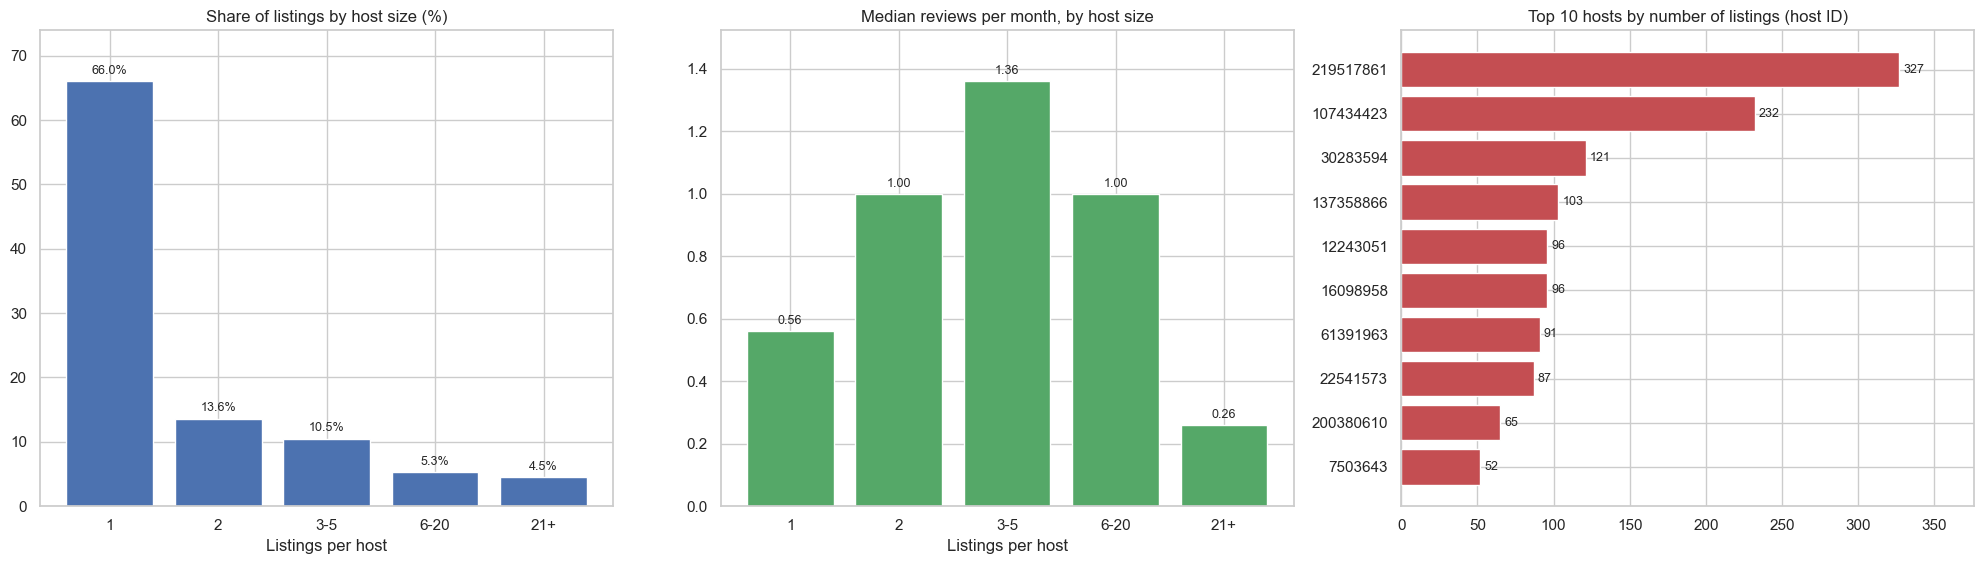

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
os.makedirs("charts", exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def label_bars(ax, fmt="{:,.0f}", suffix="", pad=3, horizontal=False):
    """Write the value on every bar (vertical or horizontal)."""
    for c in ax.containers:
        ax.bar_label(c, labels=[(fmt.format(v) + suffix) if np.isfinite(v) else "" for v in c.datavalues],
                     padding=pad, fontsize=9)
    if horizontal: ax.margins(x=0.15)
    else:          ax.margins(y=0.12)

df["has_review"] = (df.number_of_reviews > 0).astype(int)
df["is_entire"] = (df.room_type == "Entire home/apt").astype(int)
df["is_closed"] = (df.availability_365 == 0).astype(int)
valid = df[df.price_valid == 1]

# --- 1) host overview ---
per_host = df.groupby("host_id").size()
n_hosts = per_host.size
print("Hosts:", n_hosts, "| listings:", len(df), "| avg listings per host: %.2f" % per_host.mean())
print("Hosts with 1 listing: %d (%.1f%%)" % ((per_host == 1).sum(), (per_host == 1).mean()*100))
print("Hosts with 2+ listings: %d (%.1f%%), owning %.1f%% of listings" % (
      (per_host > 1).sum(), (per_host > 1).mean()*100, per_host[per_host > 1].sum()/len(df)*100))
print("Top 10 hosts own %.1f%% of listings | top 1%% of hosts own %.1f%%\n" % (
      per_host.nlargest(10).sum()/len(df)*100,
      per_host.nlargest(int(np.ceil(n_hosts*0.01))).sum()/len(df)*100))

# --- 2) host size bands ---
df["host_band"] = pd.cut(df.calculated_host_listings_count, [0,1,2,5,20,1000], labels=["1","2","3-5","6-20","21+"])
valid = df[df.price_valid == 1]
hb = df.groupby("host_band", observed=True).agg(
    hosts=("host_id","nunique"), listings=("id","count"),
    pct_entire_home=("is_entire", lambda s: round(s.mean()*100,1)),
    pct_closed=("is_closed", lambda s: round(s.mean()*100,1)),
    pct_reviewed=("has_review", lambda s: round(s.mean()*100,1)))
hb["share_of_listings_%"] = (hb.listings/hb.listings.sum()*100).round(1)
hb["median_price"] = valid.groupby("host_band", observed=True).price.median()
hb["median_reviews_per_month"] = (df[df.has_review == 1]
        .groupby("host_band", observed=True).reviews_per_month.median().round(2))
print("1) Host size bands (listings per host)\n", hb, "\n")

# --- 3) top 10 hosts ---
top = (df.groupby(["host_id","host_name"]).agg(
        listings=("id","count"), boroughs=("neighbourhood_group","nunique"),
        main_borough=("neighbourhood_group", lambda s: s.mode().iloc[0]),
        pct_entire_home=("is_entire", lambda s: round(s.mean()*100)),
        median_price=("price","median"))
       .reset_index().sort_values("listings", ascending=False).head(10))
print("2) Top 10 hosts by listings\n", top, "\n")

# --- 4) by borough ---
boro = df.groupby("neighbourhood_group").agg(
        listings=("id","count"),
        pct_by_multi_hosts=("calculated_host_listings_count", lambda s: round((s>1).mean()*100,1)),
        pct_by_6plus_hosts=("calculated_host_listings_count", lambda s: round((s>=6).mean()*100,1)))
print("3) Share of listings owned by multi-listing hosts, by borough\n", boro)

# --- charts (the chart shows host ID, not host names) ---
fig, ax = plt.subplots(1, 3, figsize=(20, 5.8))

ax[0].bar(hb.index.astype(str), hb["share_of_listings_%"].values, color=sns.color_palette("deep")[0])
ax[0].set_title("Share of listings by host size (%)"); ax[0].set_xlabel("Listings per host")
label_bars(ax[0], "{:.1f}", "%")

ax[1].bar(hb.index.astype(str), hb.median_reviews_per_month.values, color=sns.color_palette("deep")[2])
ax[1].set_title("Median reviews per month, by host size"); ax[1].set_xlabel("Listings per host")
label_bars(ax[1], "{:.2f}")

t = top.iloc[::-1]
ax[2].barh(t.host_id.astype(str), t.listings.values, color=sns.color_palette("deep")[3])
ax[2].set_title("Top 10 hosts by number of listings (host ID)")
label_bars(ax[2], "{:,.0f}", horizontal=True)

plt.tight_layout()
plt.savefig("charts/07_host_profile.png", dpi=150, bbox_inches="tight")
plt.show()

1) Availability bands (days open per year)
             listings  share_%
0 (closed)     17500     35.8
1-90           11704     24.0
91-180          5281     10.8
181-270         4510      9.2
271-365         9824     20.1 

Median availability of open listings (1+ days): 167 days

% closed (0 days) by borough: {'Brooklyn': 39.0, 'Manhattan': 37.4, 'Queens': 24.1, 'Bronx': 16.3, 'Staten Island': 11.3}
% closed (0 days) by room type: {'Private room': 37.4, 'Entire home/apt': 34.9, 'Shared room': 25.6} 

2) Minimum nights
         listings  share_%
1          12688     26.0
2          11692     23.9
3           7996     16.4
4-7         9135     18.7
8-30        6578     13.5
31-365       730      1.5 

% with minimum nights 8+ by borough: {'Bronx': 5.9, 'Brooklyn': 12.3, 'Manhattan': 19.3, 'Queens': 10.4, 'Staten Island': 7.0}
% with minimum nights 8+ by room type: {'Entire home/apt': 18.4, 'Private room': 11.1, 'Shared room': 14.4} 

3) Activity status (from last review date)
        

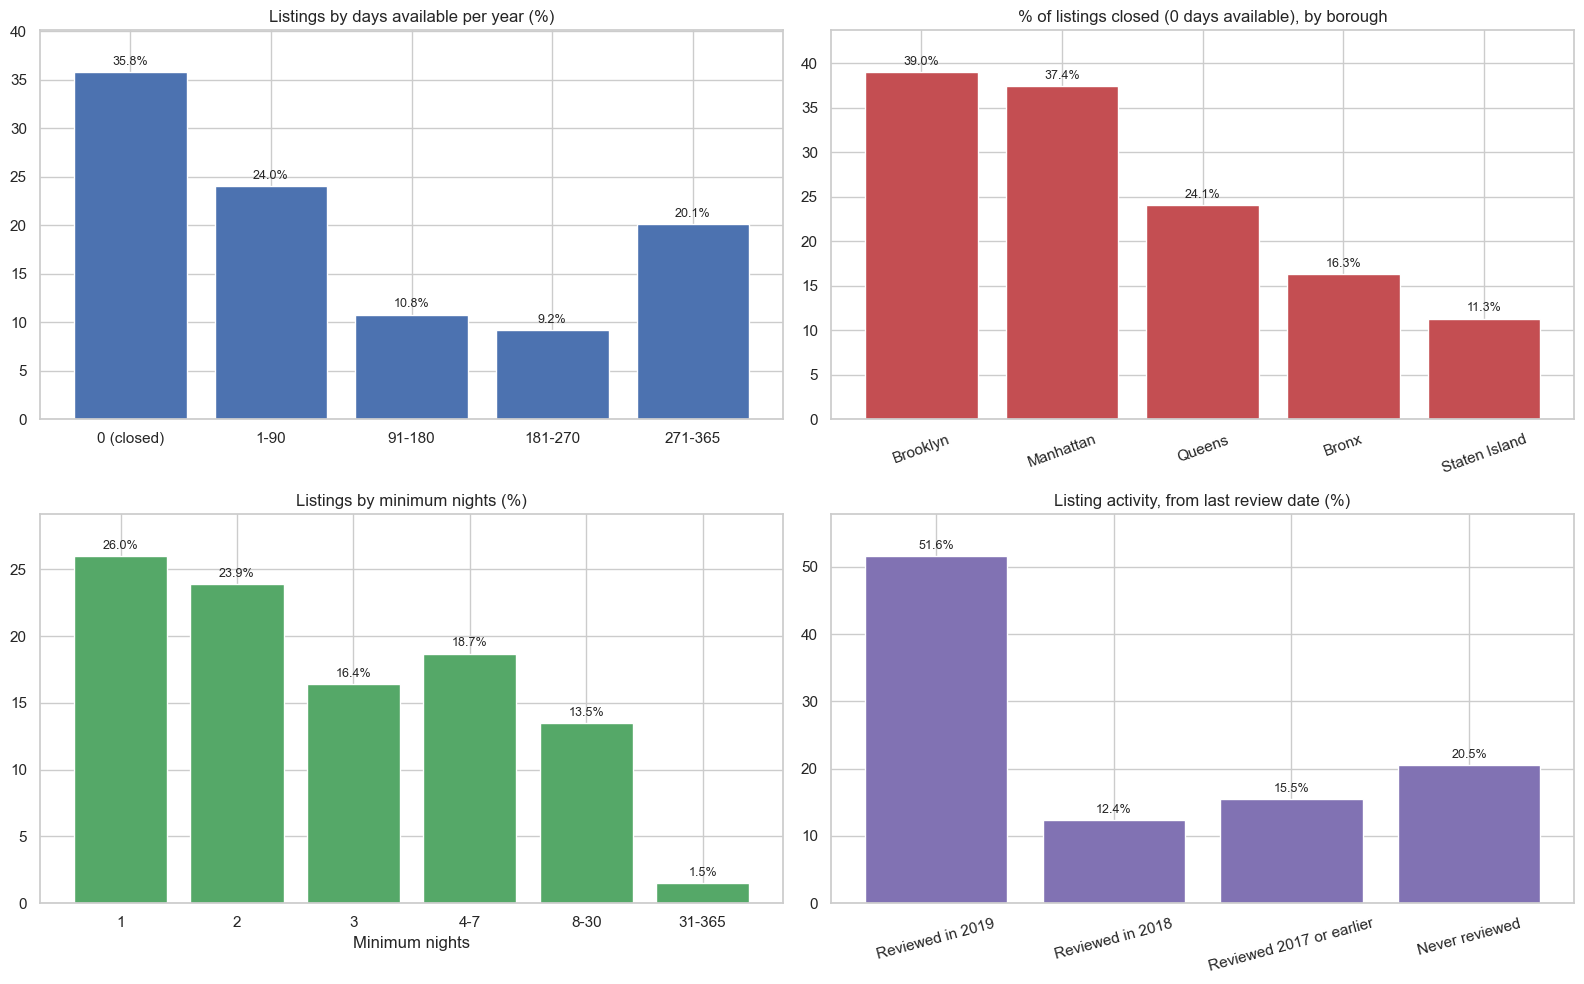

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
os.makedirs("charts", exist_ok=True)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def label_bars(ax, fmt="{:,.0f}", suffix="", pad=3, horizontal=False):
    """Write the value on every bar (vertical or horizontal)."""
    for c in ax.containers:
        ax.bar_label(c, labels=[(fmt.format(v) + suffix) if np.isfinite(v) else "" for v in c.datavalues],
                     padding=pad, fontsize=9)
    if horizontal: ax.margins(x=0.15)
    else:          ax.margins(y=0.12)

def pct(s): return round(s.mean() * 100, 1)

df["is_closed"] = (df.availability_365 == 0).astype(int)
df["avail_band"] = pd.cut(df.availability_365, [-1,0,90,180,270,365],
                          labels=["0 (closed)","1-90","91-180","181-270","271-365"])
df["min_nights_band"] = pd.cut(df.minimum_nights, [0,1,2,3,7,30,365],
                               labels=["1","2","3","4-7","8-30","31-365"])

def activity(d):
    if pd.isna(d): return "Never reviewed"
    if d >= pd.Timestamp("2019-01-01"): return "Reviewed in 2019"
    if d >= pd.Timestamp("2018-01-01"): return "Reviewed in 2018"
    return "Reviewed 2017 or earlier"
df["activity"] = df.last_review.apply(activity)
act_order = ["Reviewed in 2019", "Reviewed in 2018", "Reviewed 2017 or earlier", "Never reviewed"]

# --- 1) availability ---
av = df.avail_band.value_counts().reindex(df.avail_band.cat.categories)
av_pct = (av / av.sum() * 100).round(1)
print("1) Availability bands (days open per year)\n", pd.DataFrame({"listings": av, "share_%": av_pct}), "\n")
print("Median availability of open listings (1+ days): %d days\n" % df.loc[df.availability_365 > 0, "availability_365"].median())

closed_boro = df.groupby("neighbourhood_group").is_closed.apply(pct).sort_values(ascending=False)
closed_room = df.groupby("room_type").is_closed.apply(pct).sort_values(ascending=False)
print("% closed (0 days) by borough:", closed_boro.to_dict())
print("% closed (0 days) by room type:", closed_room.to_dict(), "\n")

# --- 2) minimum nights ---
mn = df.min_nights_band.value_counts().reindex(df.min_nights_band.cat.categories)
mn_pct = (mn / mn.sum() * 100).round(1)
print("2) Minimum nights\n", pd.DataFrame({"listings": mn, "share_%": mn_pct}), "\n")
print("% with minimum nights 8+ by borough:", df.groupby("neighbourhood_group").minimum_nights.apply(lambda s: pct(s >= 8)).to_dict())
print("% with minimum nights 8+ by room type:", df.groupby("room_type").minimum_nights.apply(lambda s: pct(s >= 8)).to_dict(), "\n")

# --- 3) activity status ---
ac = df.activity.value_counts().reindex(act_order)
ac_pct = (ac / ac.sum() * 100).round(1)
print("3) Activity status (from last review date)\n", pd.DataFrame({"listings": ac, "share_%": ac_pct}), "\n")
print("% closed by activity status:\n", df.groupby("activity").is_closed.apply(pct).reindex(act_order), "\n")

dormant = df[(df.is_closed == 1) & (df.activity.isin(["Reviewed 2017 or earlier", "Never reviewed"]))]
print("Likely dormant listings (closed AND no review since 2018): %d (%.1f%% of listings)\n" % (len(dormant), len(dormant)/len(df)*100))
print("Dormant share by borough (%):", (dormant.neighbourhood_group.value_counts() / df.neighbourhood_group.value_counts() * 100).round(1).to_dict())

# --- charts ---
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

ax[0,0].bar(av_pct.index.astype(str), av_pct.values, color=sns.color_palette("deep")[0])
ax[0,0].set_title("Listings by days available per year (%)"); label_bars(ax[0,0], "{:.1f}", "%")

ax[0,1].bar(closed_boro.index, closed_boro.values, color=sns.color_palette("deep")[3])
ax[0,1].set_title("% of listings closed (0 days available), by borough"); ax[0,1].tick_params(axis="x", rotation=20)
label_bars(ax[0,1], "{:.1f}", "%")

ax[1,0].bar(mn_pct.index.astype(str), mn_pct.values, color=sns.color_palette("deep")[2])
ax[1,0].set_title("Listings by minimum nights (%)"); ax[1,0].set_xlabel("Minimum nights")
label_bars(ax[1,0], "{:.1f}", "%")

ax[1,1].bar(ac_pct.index, ac_pct.values, color=sns.color_palette("deep")[4])
ax[1,1].set_title("Listing activity, from last review date (%)"); ax[1,1].tick_params(axis="x", rotation=15)
label_bars(ax[1,1], "{:.1f}", "%")

plt.tight_layout()
plt.savefig("charts/08_operations.png", dpi=150, bbox_inches="tight")
plt.show()

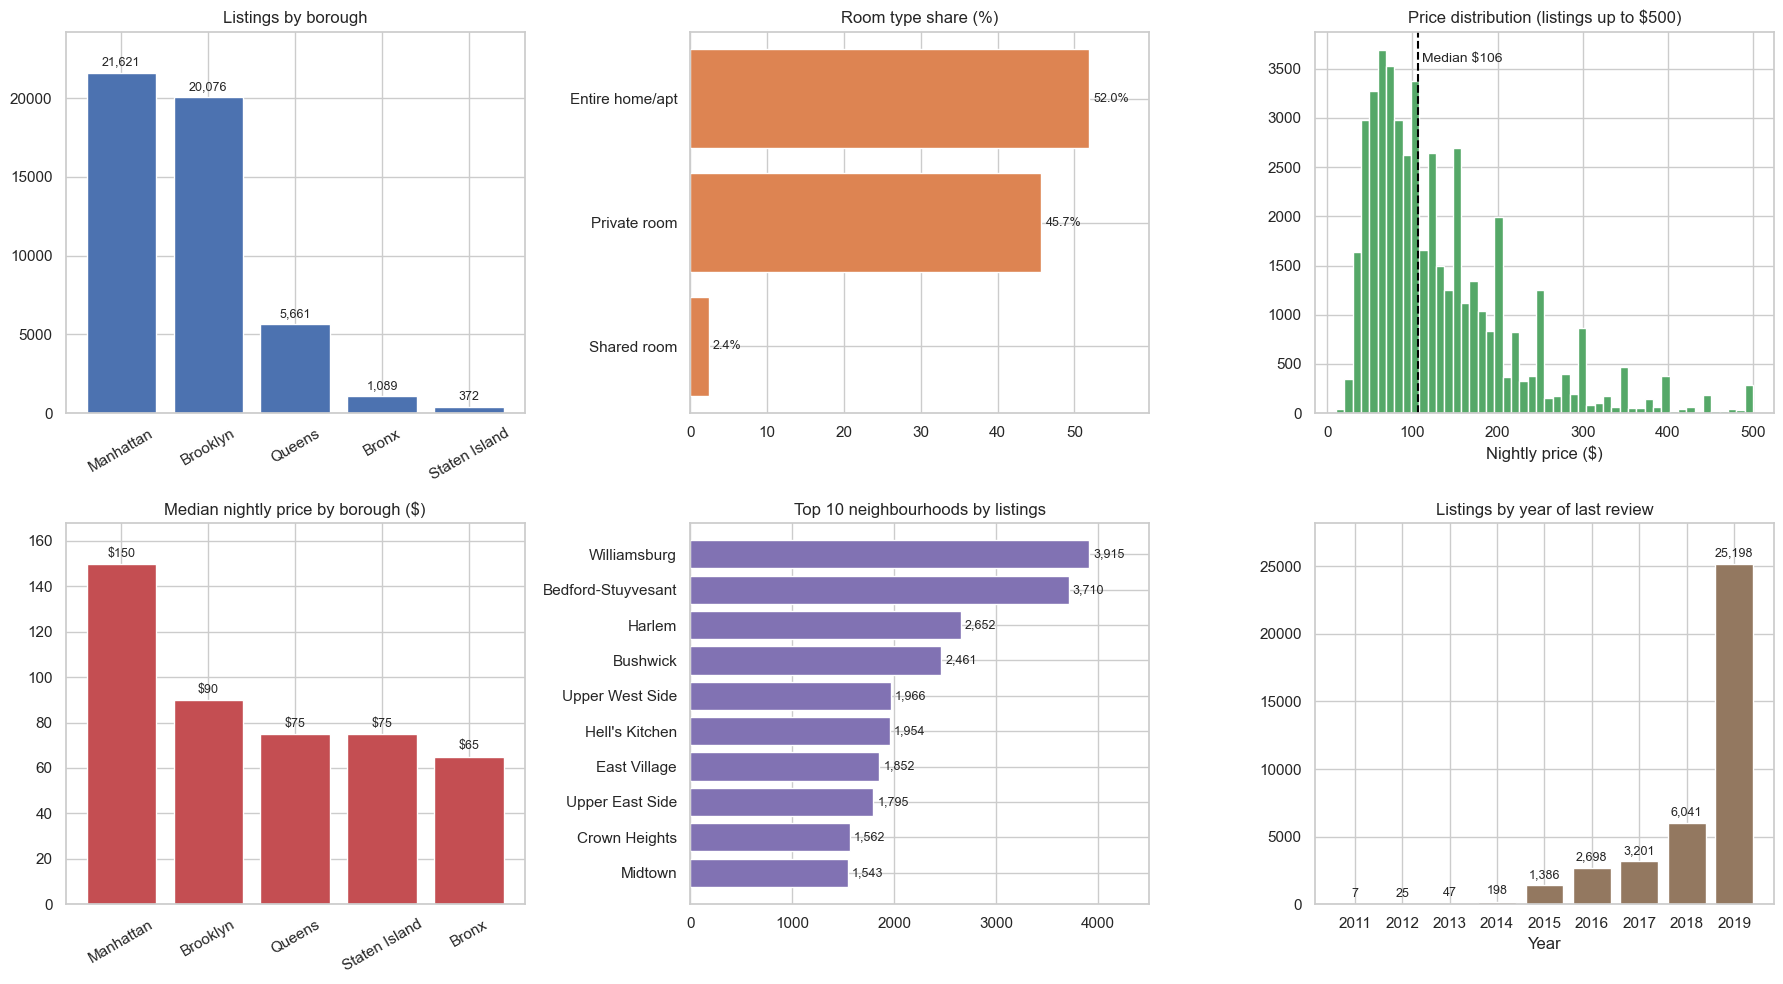

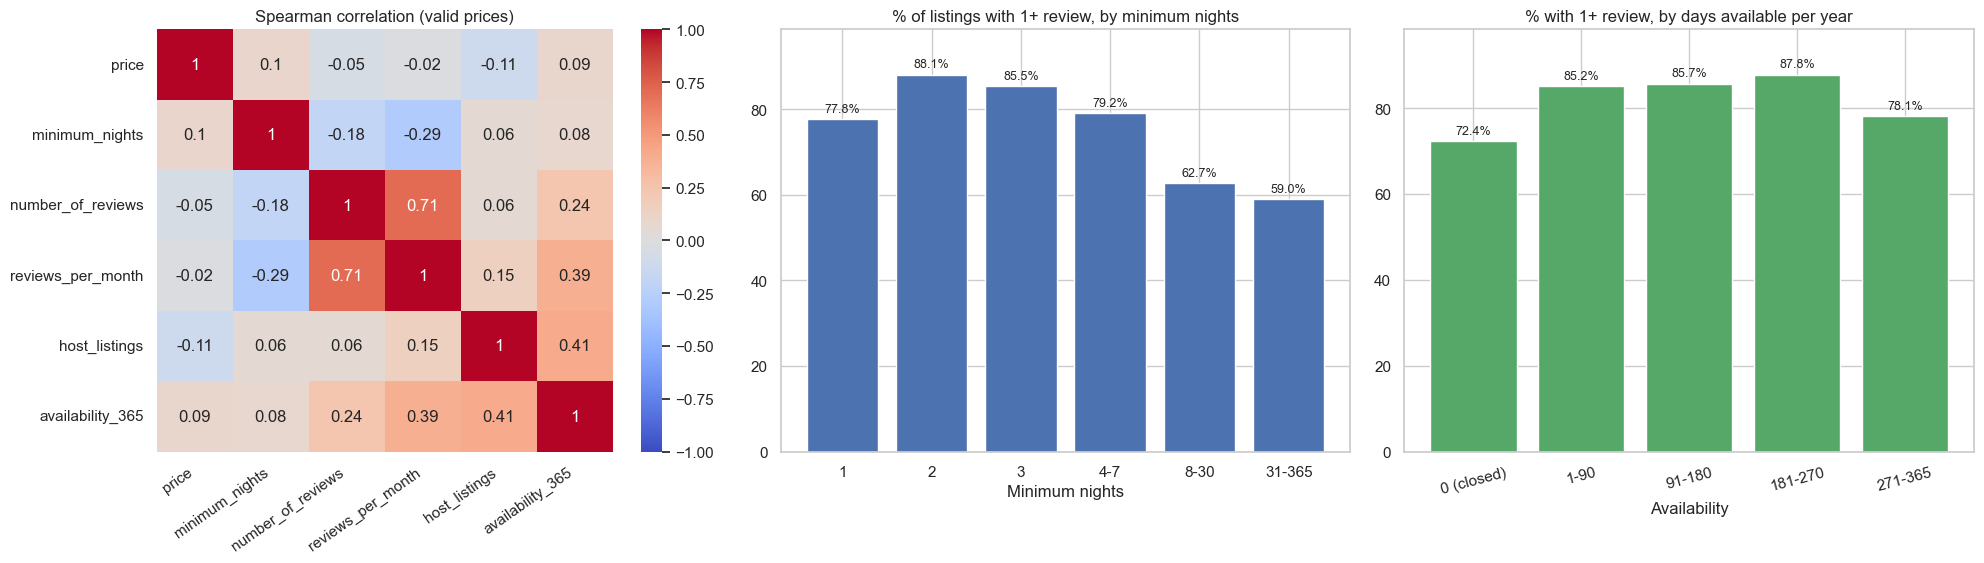

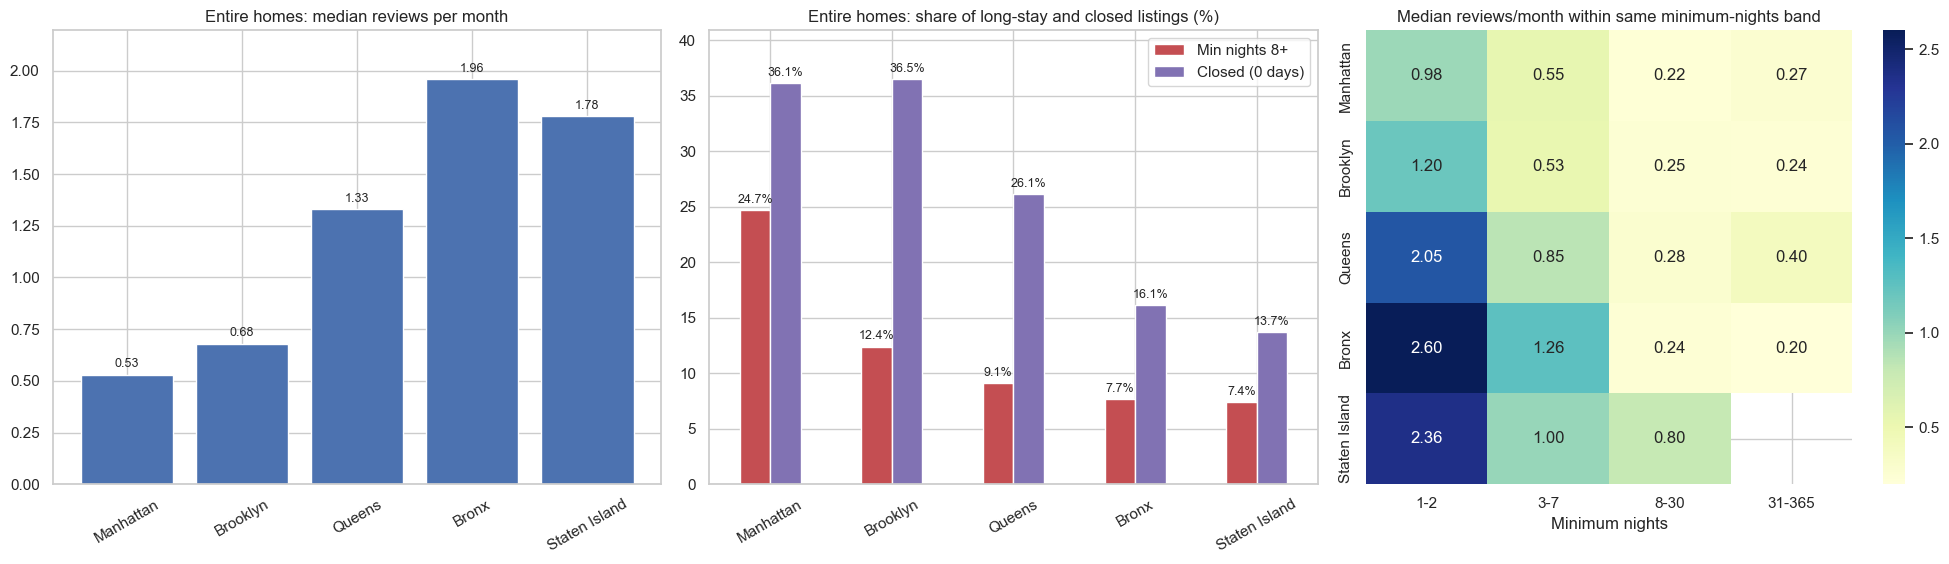

Charts refreshed: ['01_overview.png', '03_drivers_corr_bands.png', '04_drilldown_manhattan.png']


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
os.makedirs("charts", exist_ok=True)
pal = sns.color_palette("deep")

def label_bars(ax, fmt="{:,.0f}", suffix="", pad=3, horizontal=False):
    """Write the value on every bar (vertical or horizontal, single or grouped)."""
    for c in ax.containers:
        ax.bar_label(c, labels=[(fmt.format(v) + suffix) if np.isfinite(v) else "" for v in c.datavalues],
                     padding=pad, fontsize=9)
    if horizontal: ax.margins(x=0.15)
    else:          ax.margins(y=0.12)

# ---------- data prep ----------
df["has_review"] = (df.number_of_reviews > 0).astype(int)
valid = df[df.price_valid == 1]
reviewed = df[df.has_review == 1]
order = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]

# =====================  CHART 01: OVERVIEW  =====================
borough = (df.groupby("neighbourhood_group").agg(listings=("id", "count"))
             .join(valid.groupby("neighbourhood_group").price.median().rename("median_price"))
             .sort_values("listings", ascending=False))
room = (df.groupby("room_type").agg(listings=("id", "count"))
          .sort_values("listings", ascending=False))
room["share"] = room.listings / room.listings.sum() * 100
top_n = df["neighbourhood"].value_counts().head(10)
by_year = df["last_review"].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0,0].bar(borough.index, borough.listings.values, color=pal[0])
ax[0,0].set_title("Listings by borough"); ax[0,0].tick_params(axis="x", rotation=30)
label_bars(ax[0,0])

ax[0,1].barh(room.index[::-1], room.share.values[::-1], color=pal[1])
ax[0,1].set_title("Room type share (%)"); label_bars(ax[0,1], "{:.1f}", "%", horizontal=True)

p = valid.loc[valid.price <= 500, "price"]
ax[0,2].hist(p, bins=50, color=pal[2])
ax[0,2].axvline(valid.price.median(), color="black", linestyle="--")
ax[0,2].text(valid.price.median() + 5, ax[0,2].get_ylim()[1] * 0.92, f"Median ${valid.price.median():.0f}", fontsize=10)
ax[0,2].set_title("Price distribution (listings up to $500)"); ax[0,2].set_xlabel("Nightly price ($)")

m = borough.median_price.sort_values(ascending=False)
ax[1,0].bar(m.index, m.values, color=pal[3])
ax[1,0].set_title("Median nightly price by borough ($)"); ax[1,0].tick_params(axis="x", rotation=30)
label_bars(ax[1,0], "${:,.0f}")

ax[1,1].barh(top_n.index[::-1], top_n.values[::-1], color=pal[4])
ax[1,1].set_title("Top 10 neighbourhoods by listings"); label_bars(ax[1,1], "{:,.0f}", horizontal=True)

ax[1,2].bar(by_year.index.astype(int).astype(str), by_year.values, color=pal[5])
ax[1,2].set_title("Listings by year of last review"); ax[1,2].set_xlabel("Year")
label_bars(ax[1,2])

plt.tight_layout(); plt.savefig("charts/01_overview.png", dpi=150, bbox_inches="tight"); plt.show()

# =====================  CHART 03: CORRELATION + BANDS  =====================
df["min_nights_band"] = pd.cut(df.minimum_nights, [0,1,2,3,7,30,365], labels=["1","2","3","4-7","8-30","31-365"])
df["avail_band"] = pd.cut(df.availability_365, [-1,0,90,180,270,365],
                          labels=["0 (closed)","1-90","91-180","181-270","271-365"])
mn_rev = df.groupby("min_nights_band", observed=True).has_review.mean().mul(100).round(1)
av_rev = df.groupby("avail_band", observed=True).has_review.mean().mul(100).round(1)
num_cols = ["price","minimum_nights","number_of_reviews","reviews_per_month","calculated_host_listings_count","availability_365"]
corr = valid[num_cols].corr(method="spearman").round(2)
short = lambda cols: [c.replace("calculated_host_listings_count", "host_listings") for c in cols]

fig, ax = plt.subplots(1, 3, figsize=(20, 5.8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title("Spearman correlation (valid prices)")
ax[0].set_xticklabels(short(corr.columns), rotation=35, ha="right"); ax[0].set_yticklabels(short(corr.index), rotation=0)
ax[1].bar(mn_rev.index.astype(str), mn_rev.values, color=pal[0])
ax[1].set_title("% of listings with 1+ review, by minimum nights"); ax[1].set_xlabel("Minimum nights")
label_bars(ax[1], "{:.1f}", "%")
ax[2].bar(av_rev.index.astype(str), av_rev.values, color=pal[2])
ax[2].set_title("% with 1+ review, by days available per year"); ax[2].set_xlabel("Availability"); ax[2].tick_params(axis="x", rotation=15)
label_bars(ax[2], "{:.1f}", "%")
plt.tight_layout(); plt.savefig("charts/03_drivers_corr_bands.png", dpi=150, bbox_inches="tight"); plt.show()

# =====================  CHART 04: DRILL-DOWN  =====================
entire = df[df.room_type == "Entire home/apt"].copy()
entire["mn_band"] = pd.cut(entire.minimum_nights, [0,2,7,30,365], labels=["1-2","3-7","8-30","31-365"])
ent_rev = entire[entire.has_review == 1]
overall = ent_rev.groupby("neighbourhood_group").reviews_per_month.median().round(2).reindex(order)
mix = pd.DataFrame({
    "Min nights 8+":   entire.groupby("neighbourhood_group").minimum_nights.apply(lambda s: round((s >= 8).mean()*100, 1)),
    "Closed (0 days)": entire.groupby("neighbourhood_group").availability_365.apply(lambda s: round((s == 0).mean()*100, 1)),
}).reindex(order)
by_mn = ent_rev.pivot_table(index="neighbourhood_group", columns="mn_band", values="reviews_per_month",
                            aggfunc="median", observed=True).round(2).reindex(order)

fig, ax = plt.subplots(1, 3, figsize=(20, 5.8))
ax[0].bar(order, overall.values, color=pal[0])
ax[0].set_title("Entire homes: median reviews per month"); ax[0].tick_params(axis="x", rotation=30)
label_bars(ax[0], "{:.2f}")
mix.plot(kind="bar", ax=ax[1], color=[pal[3], pal[4]])
ax[1].set_title("Entire homes: share of long-stay and closed listings (%)")
ax[1].tick_params(axis="x", rotation=30); ax[1].set_xlabel("")
label_bars(ax[1], "{:.1f}", "%")
sns.heatmap(by_mn, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax[2])
ax[2].set_title("Median reviews/month within same minimum-nights band"); ax[2].set_xlabel("Minimum nights"); ax[2].set_ylabel("")
plt.tight_layout(); plt.savefig("charts/04_drilldown_manhattan.png", dpi=150, bbox_inches="tight"); plt.show()

print("Charts refreshed:", sorted(f for f in os.listdir("charts") if f[:2] in ("01", "03", "04")))

In [15]:
import os
import numpy as np
import pandas as pd

project_dir = r"D:\Kagal\New York City Airbnb Open Data\nyc-airbnb-dashboard"
os.makedirs(project_dir, exist_ok=True)

app_df = df.copy()
app_df["has_review"] = (app_df.number_of_reviews > 0).astype(int)

def activity(d):
    if pd.isna(d): return "Never reviewed"
    if d >= pd.Timestamp("2019-01-01"): return "Reviewed in 2019"
    if d >= pd.Timestamp("2018-01-01"): return "Reviewed in 2018"
    return "Reviewed 2017 or earlier"

app_df["activity_status"] = app_df.last_review.apply(activity)
app_df["is_closed"] = (app_df.availability_365 == 0).astype(int)
app_df["likely_dormant"] = ((app_df.is_closed == 1) &
        app_df.activity_status.isin(["Reviewed 2017 or earlier", "Never reviewed"])).astype(int)

cols = ["id", "host_id", "neighbourhood_group", "neighbourhood", "latitude", "longitude", "room_type",
        "price", "minimum_nights", "number_of_reviews", "last_review", "reviews_per_month",
        "calculated_host_listings_count", "availability_365", "price_valid",
        "has_review", "activity_status", "is_closed", "likely_dormant"]
app_df = app_df[cols]

out = os.path.join(project_dir, "nyc_airbnb_clean.csv")
app_df.to_csv(out, index=False)

# --- verify the file by re-reading it from disk ---
check = pd.read_csv(out, parse_dates=["last_review"])
print("Saved to:", out)
print("File size (MB): %.2f" % (os.path.getsize(out) / 1e6))
print("Shape:", check.shape)
print("Unique ids:", check.id.nunique())
print("price_valid:", check.price_valid.value_counts().to_dict())
print("has_review:", check.has_review.value_counts().to_dict())
print("likely_dormant:", check.likely_dormant.sum())
print("Nulls:", check.isna().sum()[check.isna().sum() > 0].to_dict())
print("Dates:", check.last_review.min().date(), "to", check.last_review.max().date())
print(list(check.columns))

Saved to: D:\Kagal\New York City Airbnb Open Data\nyc-airbnb-dashboard\nyc_airbnb_clean.csv
File size (MB): 6.15
Shape: (48819, 19)
Unique ids: 48819
price_valid: {1: 48808, 0: 11}
has_review: {1: 38801, 0: 10018}
likely_dormant: 11067
Nulls: {'last_review': 10018, 'reviews_per_month': 10018}
Dates: 2011-03-28 to 2019-07-08
['id', 'host_id', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'price_valid', 'has_review', 'activity_status', 'is_closed', 'likely_dormant']
